### RaschPy anchor calibration worked example

Anchor calibration places a new calibration on the same scale as an external reference, using a subset of "anchor" elements in common with that reference to compute a translation constant. RaschPy supports two distinct anchoring workflows:

1. **Item-bank anchoring** (`SLM`, `RSM`, `PCM`) — anchor a new item calibration onto a bank of previously-calibrated item locations (e.g. for vertical scaling, or linking test forms).
2. **Rater anchoring** (`MFRM`) — anchor a set of raters' severities to a common zero point (e.g. a set of "gold standard" raters), so scores from different rating occasions are comparable.

Both automatically down-weight or exclude outlier anchor elements, so a handful of stale or misbehaving anchors can't distort the shift applied to the rest of the scale.

#### Item-bank anchoring (SLM / RSM / PCM)

In [1]:
import raschpy as rp

Simulate a data set and calibrate it as usual.

In [2]:
sim = rp.SLM_Sim(no_of_items=15, no_of_persons=500, item_range=3, seed=1)
slm = rp.SLM(sim)
slm.calibrate()

Suppose 10 of these items are also in an external item bank, calibrated previously on a large reference sample. We'll use their true generating locations as that "bank" here — except for Item_3, whose bank value we deliberately corrupt by 3 logits, to simulate a stale or misbehaving anchor:

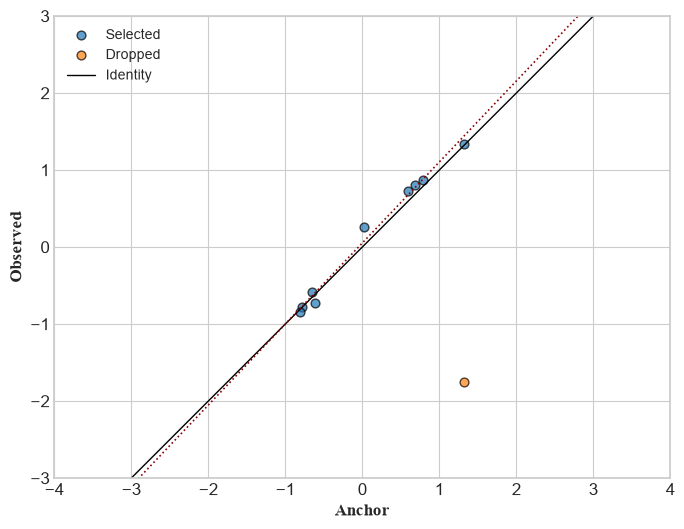

In [3]:
bank_items = list(sim.items.index[:10])
bank_locations = sim.items.loc[bank_items].copy()
bank_locations['Item_3'] += 3.0   # deliberately corrupted anchor value

slm.calibrate_anchor(bank_locations)

`anchor_summary` gives a one-line overview: how many anchors were supplied/common/selected/dropped, the correlation and SD ratio before and after trimming, and the translation constant applied.

In [4]:
slm.anchor_summary

Anchors supplied        10.000000
Anchors common          10.000000
Anchors selected         9.000000
Anchors dropped          1.000000
Original corr            0.436853
Original SD ratio        1.162421
Final corr               0.993553
Final SD ratio           1.058994
Translation constant    -0.055669
Name: Anchor calibration, dtype: float64

`anchor_selection` gives the full per-anchor-item diagnostics. Item_3 — the deliberately corrupted one — should be the only one excluded (`Selected=False`), and the correlation should improve substantially between the "before trimming" and "after trimming" figures in `anchor_summary` above.

In [5]:
slm.anchor_selection

,Anchor,Observed,Deviation,Robust z,Selected
Item_1,0.793341,0.865093,0.071752,0.243294,True
Item_2,-0.657076,-0.587483,0.069593,0.225100,True
Item_3,1.324099,-1.749082,-3.073182,-26.252639,False
Item_4,-0.614421,-0.728525,-0.114104,-1.322537,True
Item_5,-0.777856,-0.784091,-0.006235,-0.413746,True
Item_6,0.684367,0.807609,0.123242,0.677090,True
Item_7,-0.802992,-0.839870,-0.036878,-0.671910,True
Item_8,0.596655,0.728754,0.132099,0.751714,True
Item_9,0.015721,0.261115,0.245394,1.706217,True
Item_10,1.324099,1.340256,0.016156,-0.225100,True


`anchor_items` holds the item locations shifted onto the bank's scale. Diagnostics are plotted automatically by default (`plot=True`), accessible as `slm.anchor_plot`, or callable manually via `plot_anchor_selection()` against any `anchor_selection`-shaped table:

In [6]:
slm.anchor_items.head()

Item_1    0.793341
Item_2   -0.657076
Item_3    1.324099
Item_4   -0.614421
Item_5   -0.777856
dtype: float64

`calibrate_anchor()` is available identically on `RSM` and `PCM` — e.g. `rsm.calibrate_anchor(bank_locations)`, `pcm.calibrate_anchor(bank_locations)` — with the same `anchor_items` / `anchor_summary` / `anchor_selection` attributes.

#### Rater anchoring (MFRM)

Simulate a rating design with 6 raters. Rater_4 is deliberately made much more severe than the others (+2.5 logits) — as if, unknown to us, they shouldn't really be part of the "gold standard" anchor set.

In [7]:
sim_mfrm = rp.MFRM_Sim_Global(
    no_of_items=10, no_of_persons=300, no_of_raters=6, max_score=4,
    manual_raters={'Rater_1': 0.0, 'Rater_2': 0.1, 'Rater_3': -0.1,
                   'Rater_4': 2.5, 'Rater_5': 0.5, 'Rater_6': -0.5},
    seed=1,
)
mfrm = rp.MFRM(sim_mfrm)
mfrm.calibrate_global()

**Checking anchor rater homogeneity before anchoring**

Anchoring only constrains the *mean* severity of the chosen anchor set to zero — it has no way to notice whether that mean is a stable, shared reference point or an artefact of averaging over raters who don't behave alike. Suppose we intend to anchor to Raters 1-4. `check_anchor_homogeneity()` tests whether that proposed anchor set actually agrees with itself first:

In [8]:
anchors = ['Rater_1', 'Rater_2', 'Rater_3', 'Rater_4']
mfrm.check_anchor_homogeneity(model='global', anchors=anchors, no_of_samples=300)

mfrm.anchor_homogeneity_test        # omnibus Cochran's Q test

/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_31482/2118129591.py:2: UserWarning: Anchor rater(s) ['Rater_2', 'Rater_4'] do not appear homogeneous with the rest of the anchor set (cochran test; see anchor_homogeneity_per_rater). The anchor-defined zero point may be unstable — consider revising the anchor set.
  mfrm.check_anchor_homogeneity(model='global', anchors=anchors, no_of_samples=300)


Q                            2487.064009
df                                     3
p                                    0.0
Flagged                             True
N_dropped_for_homogeneity              2
Name: Anchor homogeneity test, dtype: object

In [9]:
mfrm.anchor_homogeneity_per_rater    # per-rater severity, SE, z, p, Flagged

,Severity,SE,z,p,Flagged
Rater_1,-0.430544,0.027463,1.489267,0.136417,False
Rater_2,-0.240719,0.029422,5.395103,0.0,True
Rater_3,-0.515849,0.028616,-1.551745,0.120723,False
Rater_4,2.029248,0.046338,46.556182,0.0,True


Rater_4 — the deliberately severe rater — is correctly flagged (sequential exclusion may also flag a second rater whose apparent position shifts once the clearest outlier is set aside; this is expected, not a bug). Given this warning, we'd revise the anchor set (e.g. drop Rater_4) before relying on it. For this walkthrough, we'll proceed anyway to see what anchoring against the flawed set looks like:

In [10]:
mfrm.calibrate_global_anchor(anchors)
mfrm.anchor_raters_global    # anchored rater severities

Rater_1   -0.641078
Rater_2   -0.451253
Rater_3   -0.726383
Rater_4    1.818714
Rater_5   -0.155016
Rater_6   -1.108189
dtype: float64

Compare against the unanchored severities — note the whole scale has shifted so that the anchor set's *mean* (including the outlier) sits at zero, which is exactly the instability the homogeneity check warned about:

In [11]:
mfrm.raters_global

Rater_1   -0.430544
Rater_2   -0.240719
Rater_3   -0.515849
Rater_4    2.029248
Rater_5    0.055518
Rater_6   -0.897655
dtype: float64

The same `calibrate_anchor(model, anchors)` / `check_anchor_homogeneity(model, anchors)` pattern works identically for the other four MFRM rater parameterisations (`'items'`, `'thresholds'`, `'bivector'`, `'matrix'`), and there are also per-model convenience aliases (e.g. `calibrate_items_anchor(anchors)`, `calibrate_matrix_anchor(anchors)`).